In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

In [11]:
data_dir = os.getcwd()

In [ ]:
import tensorflow as tf
import os

#Configuration (Set these paths correctly)
data_dir = os.getcwd() # Or your specific path
CAT_DIR = os.path.join(data_dir, 'Cat')
DOG_DIR = os.path.join(data_dir, 'Dog')

def find_bad_files(directory):
    """
    Iterates through a directory, attempts to read and decode each image,
    and reports any file that causes a TensorFlow error.
    """
    print(f"\nScanning directory: {directory}")
    
    #Getting all file paths in the directory
    file_list = [os.path.join(directory, f) for f in os.listdir(directory)]
    
    bad_files = []
    
    for i, file_path in enumerate(file_list):
        #Skiping if it's a directory
        if os.path.isdir(file_path):
            continue
            
        try:
            #1) Reading the file contents (tf.io.read_file)
            image_bytes = tf.io.read_file(file_path)
            
            #2) Decoding the image (tf.image.decode_image) - This is where my error occurs
            #I use `decode_image` as it automatically detects the format (JPEG, PNG, etc.)
            _ = tf.image.decode_image(image_bytes)
            
            #Optional: Printing progress
            if (i + 1) % 100 == 0:
                print(f"Successfully processed {i + 1} files in {os.path.basename(directory)}.")

        except Exception as e:
            #If any exception occurs during read or decode, this file is the problem
            print(f"❌ Error detected in file: {os.path.basename(file_path)}")
            #print(f"  Error message: {e}") #Uncomment if you want the full message
            bad_files.append(file_path)
            
    print(f"Scan complete. Found {len(bad_files)} problematic files in {os.path.basename(directory)}.")
    return bad_files

#Executing the Scan
bad_cats = find_bad_files(CAT_DIR)
bad_dogs = find_bad_files(DOG_DIR)


Scanning directory: c:\Users\oshah\Downloads\PetImages\Cat
Successfully processed 100 files in Cat.
Successfully processed 200 files in Cat.
Successfully processed 300 files in Cat.
Successfully processed 400 files in Cat.
❌ Error detected in file: 10404.jpg
Successfully processed 500 files in Cat.
Successfully processed 600 files in Cat.
Successfully processed 700 files in Cat.
Successfully processed 800 files in Cat.
Successfully processed 900 files in Cat.
Successfully processed 1000 files in Cat.
Successfully processed 1100 files in Cat.
Successfully processed 1200 files in Cat.
Successfully processed 1300 files in Cat.
Successfully processed 1400 files in Cat.
Successfully processed 1500 files in Cat.
Successfully processed 1600 files in Cat.
Successfully processed 1700 files in Cat.
Successfully processed 1800 files in Cat.
Successfully processed 1900 files in Cat.
Successfully processed 2000 files in Cat.
Successfully processed 2100 files in Cat.
Successfully processed 2200 fil

In [ ]:
import os
all_bad_files = bad_cats + bad_dogs

print(f"Total files identified for deletion: {len(all_bad_files)}")
print("-" * 30)

if all_bad_files:
    for file_path in all_bad_files:
        try:
            os.remove(file_path)
            print(f"✅ Deleted: {os.path.basename(file_path)}")
        except OSError as e:
            print(f"❌ Error deleting {os.path.basename(file_path)}: {e}")
            
    print("-" * 30)
    print("Cleanup complete. The problematic files have been deleted.")
else:
    print("No bad files were found to delete. The issue might be elsewhere if the error still persists.")

Total files identified for deletion: 11
------------------------------
✅ Deleted: 10404.jpg
✅ Deleted: 4351.jpg
✅ Deleted: 666.jpg
✅ Deleted: Thumbs.db
✅ Deleted: 11233.jpg
✅ Deleted: 11702.jpg
✅ Deleted: 11912.jpg
✅ Deleted: 2317.jpg
✅ Deleted: 2494.jpg
✅ Deleted: 9500.jpg
✅ Deleted: Thumbs.db
------------------------------
Cleanup complete. The problematic files have been deleted.


In [14]:
#Parameters
IMG_SIZE = (160, 160) #Standardize image size for the CNN
BATCH_SIZE = 32   

#Loading the Training Dataset (80% of data) ---
print("Loading Training Data...")
train_dataset = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,          #Reserved 20% for validation.
    subset="training",             #Selected the training subset.
    seed=123,                      #Setting a seed for reproducible split.
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

#Loading the Validation Dataset (The remaining 20%) ---
print("\nLoading Validation Data...")
validation_dataset = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,          #Reserved 20% for validation (must match training split).
    subset="validation",           #Selected the validation subset.
    seed=123,                      #Using the same seed for consistency.
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"\nClass names: {class_names}")

#The labels will be: 0 for 'Cat' and 1 for 'Dog' (since 'Cat' comes before 'Dog' alphabetically)

Loading Training Data...
Found 24991 files belonging to 2 classes.
Using 19993 files for training.

Loading Validation Data...
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.

Class names: ['Cat', 'Dog']


In [15]:
#Creating a rescaling layer
rescale = tf.keras.layers.Rescaling(1./255)

#Applying the rescaling to both datasets
train_dataset = train_dataset.map(lambda x, y: (rescale(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (rescale(x), y))

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  
INPUT_SHAPE = (160, 160, 3)

def build_cat_dog_cnn(input_shape):
    """
    Defines the CNN model as specified by the user.
    """
    model = Sequential([
        #Layer 1) 32 Filters
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=2,
            activation='relu',
            padding='valid',
            input_shape=input_shape
        ),
        MaxPooling2D(pool_size=(2, 2)),

        #Layer 2) 64 Filters
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            strides=2,
            activation='relu',
            padding='valid'
        ),
        MaxPooling2D(pool_size=(2, 2)),

        #Layer 3) 128 Filters
        Conv2D(
            filters=128,
            kernel_size=(3, 3),
            strides=2,
            activation='relu',
            padding='valid'
        ),
        MaxPooling2D(pool_size=(2, 2)),

        #Classification Head
        Flatten(),

        #Adding Dropout to reduce overfitting
        Dropout(0.5),
        
        #Dense Layer 1
        Dense(128, activation='relu'),

        #Dense Layer 2
        Dense(64, activation='relu'),

        #Output Layer (Binary Classification)
        Dense(1, activation='sigmoid')
    ])
    return model
model = build_cat_dog_cnn(INPUT_SHAPE)

In [ ]:
#Compiling the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 79, 79, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 19, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,233 (653.25 KB)

 Trainable params: 167,233 (653.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training Parameters
NUM_EPOCHS = 10
print(f"Starting model training for {NUM_EPOCHS} epochs...")

#Fitting the Model
history = model.fit(
    train_dataset,
    epochs=NUM_EPOCHS,
    validation_data=validation_dataset,
    verbose=1 #Showing progress bar during training
)

print("\nModel training complete!")

Starting model training for 10 epochs...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.5769 - loss: 0.6644 - val_accuracy: 0.6453 - val_loss: 0.6209
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7050 - loss: 0.5686 - val_accuracy: 0.7615 - val_loss: 0.4915
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.7466 - loss: 0.5093 - val_accuracy: 0.7859 - val_loss: 0.4603
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7780 - loss: 0.4660 - val_accuracy: 0.8037 - val_loss: 0.4237
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.8008 - loss: 0.4307 - val_accuracy: 0.8137 - val_loss: 0.3977
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8199 - loss: 0.3967 - val_accuracy: 0.8257 - val_loss: 0.3896
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.8341 - loss: 0.3686 - val_accuracy: 0.8223 - val_loss: 0.3991
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/

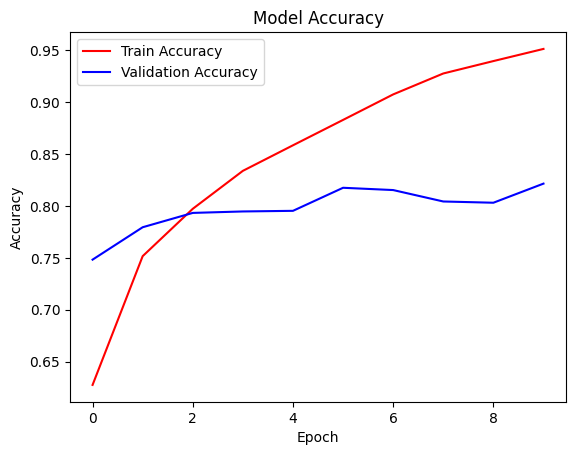

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='Train Accuracy' )
plt.plot(history.history['val_accuracy'],color='blue',label='Validation Accuracy' )
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

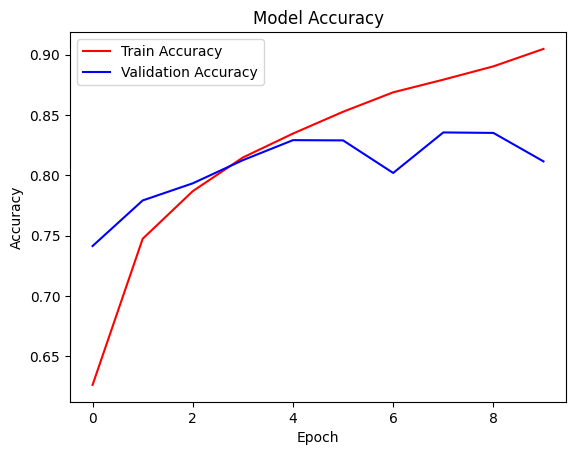

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='Train Accuracy' )
plt.plot(history.history['val_accuracy'],color='blue',label='Validation Accuracy' )
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

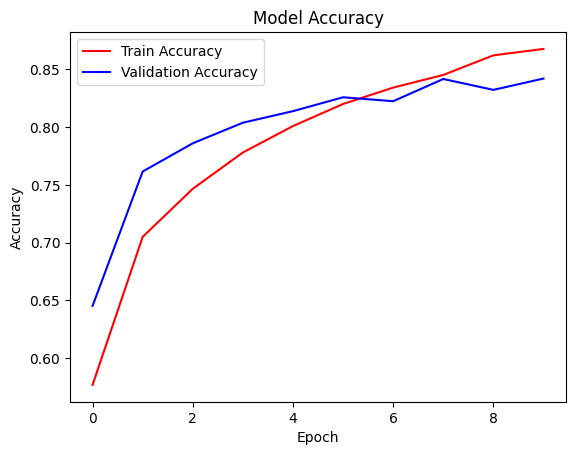

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='Train Accuracy' )
plt.plot(history.history['val_accuracy'],color='blue',label='Validation Accuracy' )
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [34]:
model.save('cat_dog_cnn_model.keras')